# Time Series Analysis — Vega at NTM Strikes

Análisis de estacionariedad y primeras diferencias del vega interpolado en cuantiles de moneyness, para calls y puts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import Button
import math
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PARQUET_PATH = r"C:\Users\pablo.esparcia\Documents\OptionMetrics\output\time_series\quantile_vega.parquet"

## 1. Carga de datos

In [2]:
quantile_vegas = pd.read_parquet(PARQUET_PATH).set_index("Date")
quantile_vegas.index = pd.to_datetime(quantile_vegas.index)

print(f"Periodo: {quantile_vegas.index.min().date()} → {quantile_vegas.index.max().date()}")
print(f"Observaciones: {len(quantile_vegas):,} | Series: {quantile_vegas.shape[1]}")
quantile_vegas.describe().round(4)

Periodo: 2003-01-02 → 2024-02-28
Observaciones: 3,968 | Series: 20


,10C,20C,30C,40C,50C,60C,70C,80C,90C,100C,10P,20P,30P,40P,50P,60P,70P,80P,90P,100P
count,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000
mean,262.0647,244.2428,185.8605,153.4537,100.1821,81.4193,48.9044,38.4179,26.6066,23.0747,17.4671,21.4729,28.7959,36.9332,53.7264,76.0716,111.4222,165.0602,233.1264,269.1742
std,124.4438,118.8776,106.5824,100.7090,87.0874,79.4853,58.9161,49.9040,40.5962,39.1047,17.7830,19.8144,24.4955,29.9673,40.7136,53.4290,70.3267,90.8537,113.7681,126.8736
min,77.2839,77.0980,10.2843,0.3116,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.8636,3.4208,4.6190,6.2588,8.9938,14.0359,24.5788,50.3647,74.8762,76.9633
25%,154.2658,145.8392,108.9462,86.6241,39.5200,25.8630,6.9862,3.6106,1.2525,0.5942,6.5552,8.4666,11.7615,15.4927,24.2398,38.1800,61.3895,95.8702,137.2440,157.9050
50%,229.3495,209.2033,137.4265,111.7516,73.0469,56.0106,28.5934,20.3788,11.4365,7.8269,11.4521,14.0484,18.9035,24.7409,38.1436,54.7439,81.8662,124.1067,199.3506,236.7556
75%,332.6120,310.9421,254.5392,204.8075,121.9121,102.7253,65.8353,51.3784,34.3741,27.9709,21.5322,28.8445,39.3527,49.1311,69.7802,97.2137,148.2860,224.5951,297.7864,342.3269
max,560.9676,517.3054,461.0262,437.0275,385.8231,383.2170,383.2170,383.2170,383.2170,383.2170,257.8266,257.8266,257.8266,257.8266,257.8266,270.3762,338.0639,414.1298,485.3889,579.9300


## 2. Series en niveles

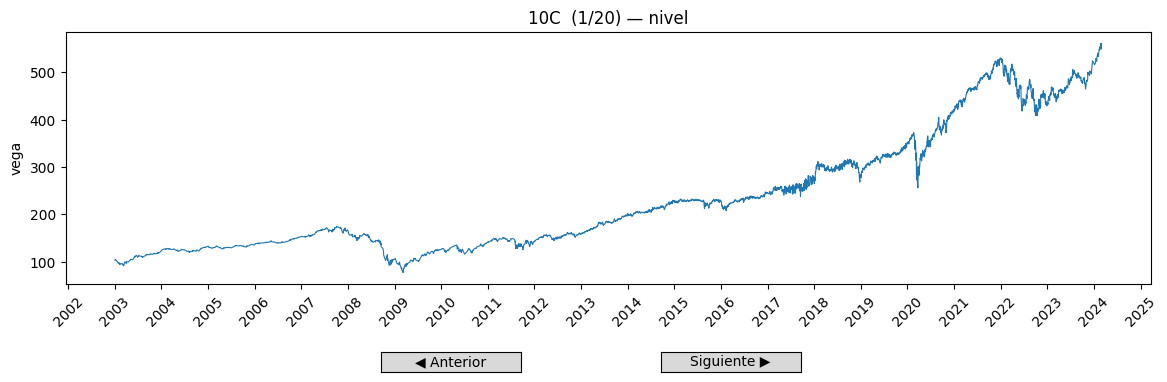

In [3]:
cols = list(quantile_vegas.columns)
idx  = [0]

fig, ax = plt.subplots(figsize=(14, 4))
plt.subplots_adjust(bottom=0.25)

def update_levels():
    col = cols[idx[0]]
    ax.cla()
    ax.plot(quantile_vegas.index, quantile_vegas[col], linewidth=0.8)
    ax.set_title(f"{col}  ({idx[0]+1}/{len(cols)}) — nivel")
    ax.set_ylabel("vega")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    fig.canvas.draw()

ax_prev = plt.axes([0.35, 0.03, 0.1, 0.05])
ax_next = plt.axes([0.55, 0.03, 0.1, 0.05])
Button(ax_prev, '◀ Anterior').on_clicked(lambda _: [idx.__setitem__(0, (idx[0]-1) % len(cols)), update_levels()])
Button(ax_next, 'Siguiente ▶').on_clicked(lambda _: [idx.__setitem__(0, (idx[0]+1) % len(cols)), update_levels()])

update_levels()
plt.show()

## 3. Test ADF — Niveles I(0)

Contraste de raíz unitaria con constante, tendencia lineal y término cuadrático (`regression='ctt'`).

- **H₀**: la serie tiene raíz unitaria (no estacionaria)
- Rechazamos H₀ si p-value < 5 %

In [4]:
rows = []
for col in quantile_vegas.columns:
    res = adfuller(quantile_vegas[col].dropna(), regression="ctt")
    rows.append({"serie": col, "p-value (%)": round(res[1]*100, 4), "estacionaria": res[1] < 0.05})


adf_diff = pd.DataFrame(rows).set_index("serie")
adf_diff.style.map(lambda v: "background-color: #d4edda; color: #155724" if v else "background-color: #f8d7da; color: #721c24",
                         subset=["estacionaria"])

,p-value (%),estacionaria
serie,,
10C,22.850200,False
20C,27.135900,False
30C,6.940200,False
40C,5.895300,False
50C,3.654600,True
60C,0.572200,True
70C,0.007600,True
80C,0.000400,True
90C,0.000200,True


## 4. Primeras diferencias porcentuales

Calculamos `pct_change()` para obtener las series I(1) y comprobamos si son estacionarias.

In [5]:
quantile_diff = quantile_vegas.pct_change().iloc[1:-1]
quantile_diff.describe().round(4)

,10C,20C,30C,40C,50C,60C,70C,80C,90C,100C,10P,20P,30P,40P,50P,60P,70P,80P,90P,100P
count,3966.0000,3966.0000,3966.0000,3966.0000,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000
mean,0.0005,0.0008,0.0162,0.1156,1.972622e+03,2.078358e+05,9.328398e+10,3.075692e+19,8.382164e+42,5.755693e+43,0.2945,0.2079,0.1311,0.0856,0.0412,0.0178,0.0062,0.0020,0.0006,0.0005
std,0.0128,0.0280,0.2289,1.5880,1.127511e+05,1.286940e+07,4.573292e+12,1.369135e+21,5.275671e+44,3.141324e+45,1.6193,1.2134,0.8416,0.6102,0.3650,0.2138,0.1149,0.0599,0.0185,0.0127
min,-0.1219,-0.2254,-0.7930,-0.9895,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-0.9595,-0.9470,-0.9189,-0.8808,-0.8157,-0.7333,-0.5941,-0.3720,-0.1172,-0.1232
25%,-0.0042,-0.0081,-0.0297,-0.0508,-1.256000e-01,-1.835000e-01,-3.993000e-01,-5.146000e-01,-6.881000e-01,-7.831000e-01,-0.1815,-0.1482,-0.1255,-0.1117,-0.0875,-0.0694,-0.0483,-0.0258,-0.0081,-0.0041
50%,0.0004,-0.0001,-0.0020,-0.0032,-4.800000e-03,-6.200000e-03,-7.300000e-03,-6.600000e-03,3.380000e-02,8.840000e-02,-0.0068,-0.0074,-0.0115,-0.0095,-0.0086,-0.0066,-0.0053,-0.0022,-0.0004,0.0007
75%,0.0055,0.0086,0.0281,0.0499,1.423000e-01,2.265000e-01,6.993000e-01,1.184200e+00,2.534900e+00,4.139200e+00,0.2380,0.1750,0.1367,0.1110,0.0889,0.0680,0.0455,0.0245,0.0082,0.0059
max,0.0940,0.3461,4.7916,48.1211,7.065917e+06,8.104235e+08,2.806655e+14,6.276431e+22,3.322416e+46,1.950271e+47,28.6729,20.6874,11.8464,8.1712,4.5952,2.5879,1.5236,1.5236,0.2491,0.0952


## 5. Test ADF — Primeras diferencias I(1)

In [6]:
rows = []
for col in quantile_diff.columns:
    res = adfuller(quantile_diff[col].dropna(), regression="ctt")
    rows.append({"serie": col, "p-value (%)": round(res[1]*100, 4), "estacionaria": res[1] < 0.05})

adf_diff = pd.DataFrame(rows).set_index("serie")
adf_diff.style.map(lambda v: "background-color: #d4edda; color: #155724" if v else "background-color: #f8d7da; color: #721c24",
                         subset=["estacionaria"])

,p-value (%),estacionaria
serie,,
10C,0.000000,True
20C,0.000000,True
30C,0.000000,True
40C,0.000500,True
50C,0.000000,True
60C,0.000000,True
70C,0.000000,True
80C,0.000000,True
90C,0.000000,True


## 6. Series en primeras diferencias

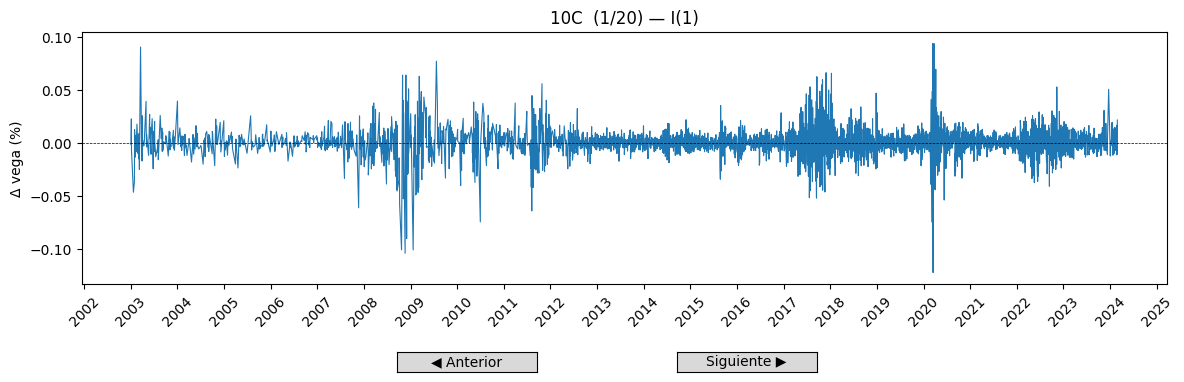

In [7]:
cols_d = list(quantile_diff.columns)
idx_d  = [0]

fig, ax = plt.subplots(figsize=(14, 4))
plt.subplots_adjust(bottom=0.25)

def update_diff():
    col = cols_d[idx_d[0]]
    ax.cla()
    ax.plot(quantile_diff.index, quantile_diff[col], linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"{col}  ({idx_d[0]+1}/{len(cols_d)}) — I(1)")
    ax.set_ylabel("Δ vega (%)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    fig.canvas.draw()

ax_prev = plt.axes([0.35, 0.03, 0.1, 0.05])
ax_next = plt.axes([0.55, 0.03, 0.1, 0.05])
Button(ax_prev, '◀ Anterior').on_clicked(lambda _: [idx_d.__setitem__(0, (idx_d[0]-1) % len(cols_d)), update_diff()])
Button(ax_next, 'Siguiente ▶').on_clicked(lambda _: [idx_d.__setitem__(0, (idx_d[0]+1) % len(cols_d)), update_diff()])

update_diff()
plt.show()

## 7. Análisis de autocorrelaciones. 
#### 7.1. Gráficas de ACF I(1):

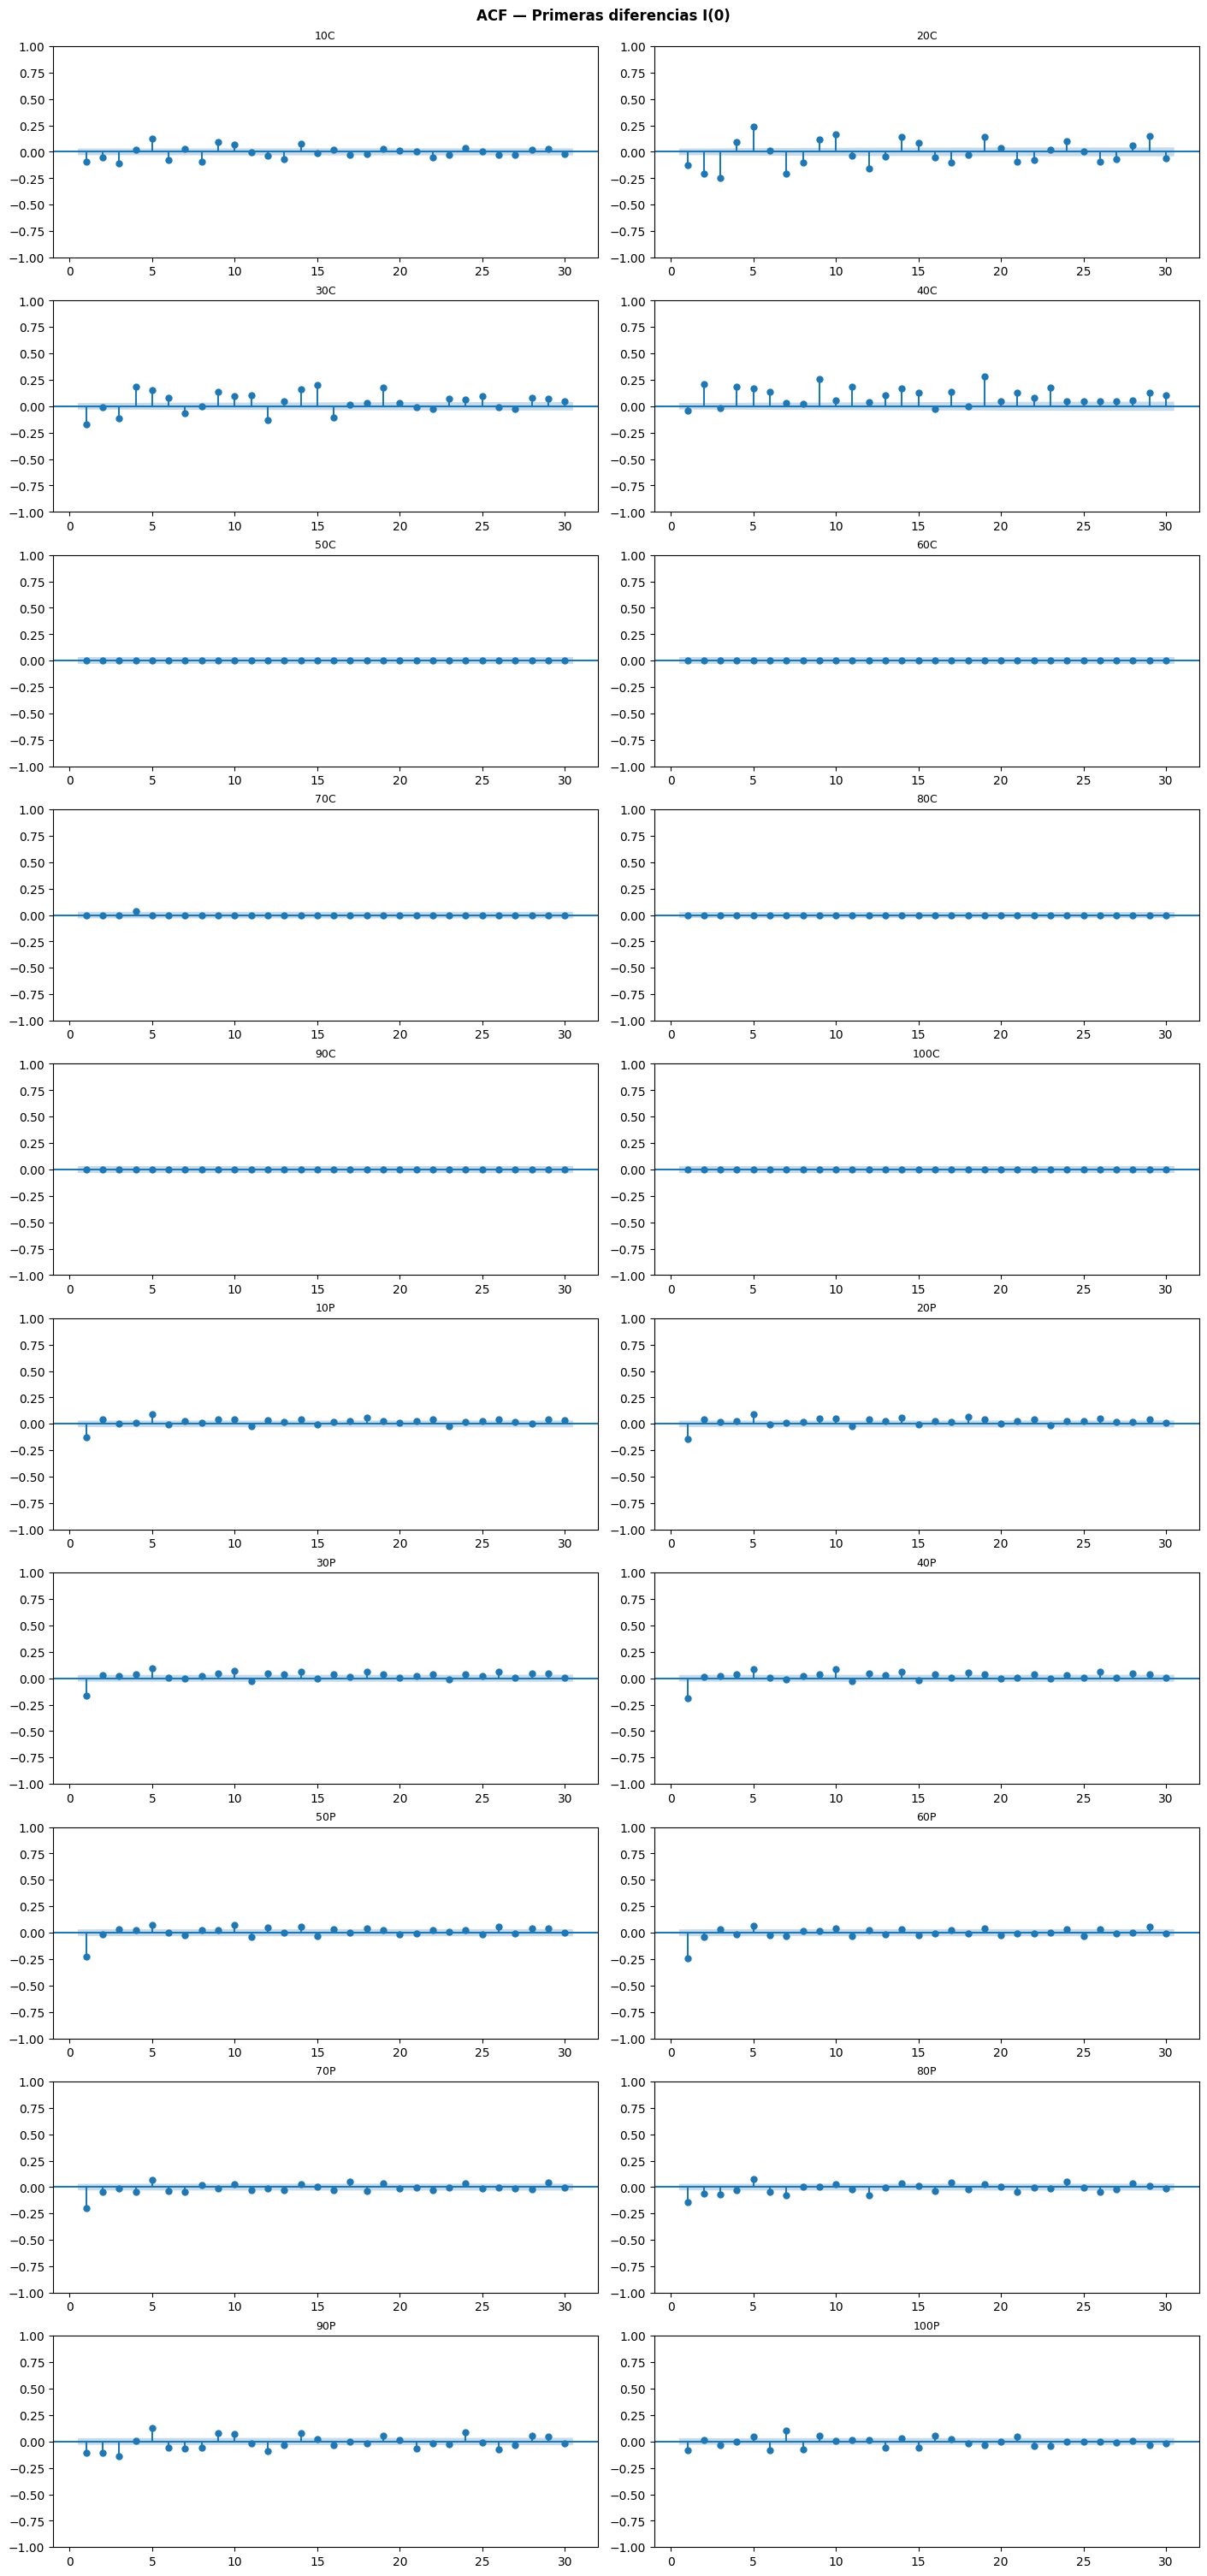

In [8]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_acf(quantile_diff[col].dropna(), lags=30, ax=axes[i], zero=False, alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("ACF — Primeras diferencias I(0)", fontsize=12, fontweight="bold")
plt.show()


#### 7.2. Gráficas de PACF I(1):

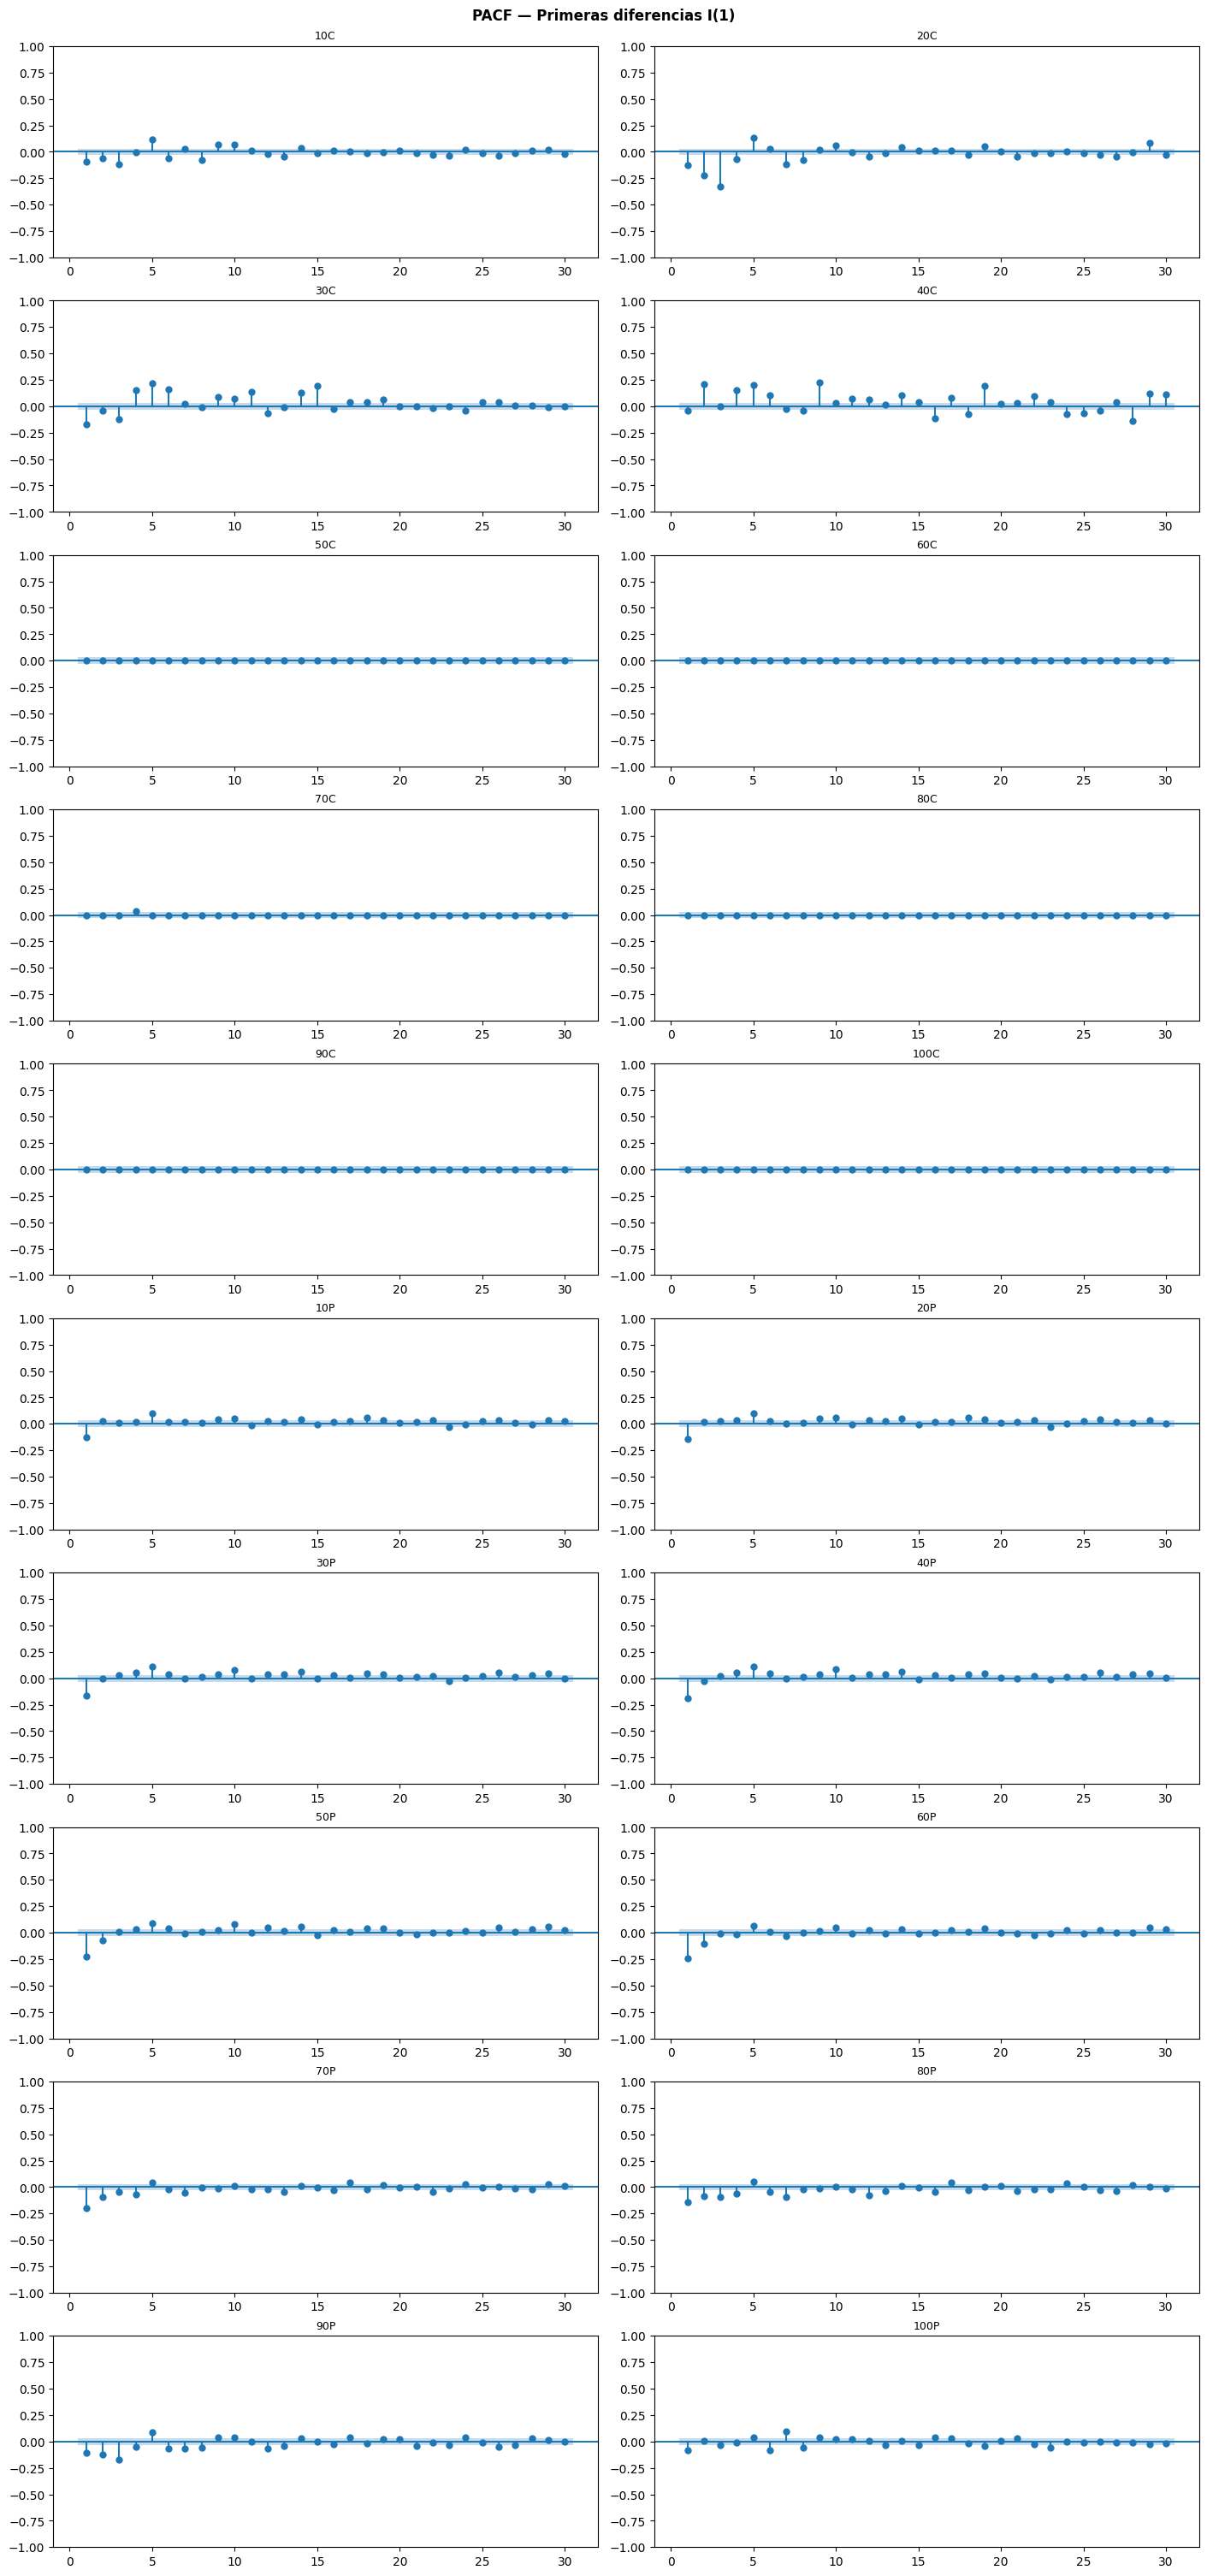

In [9]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_pacf(quantile_diff[col], lags=30, ax=axes[i], zero=False, method="ols", alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("PACF — Primeras diferencias I(1)", fontsize=12, fontweight="bold")
plt.show()


#### 7.3. Gráficas de ACF I(1) con diferencias al cuadrado:

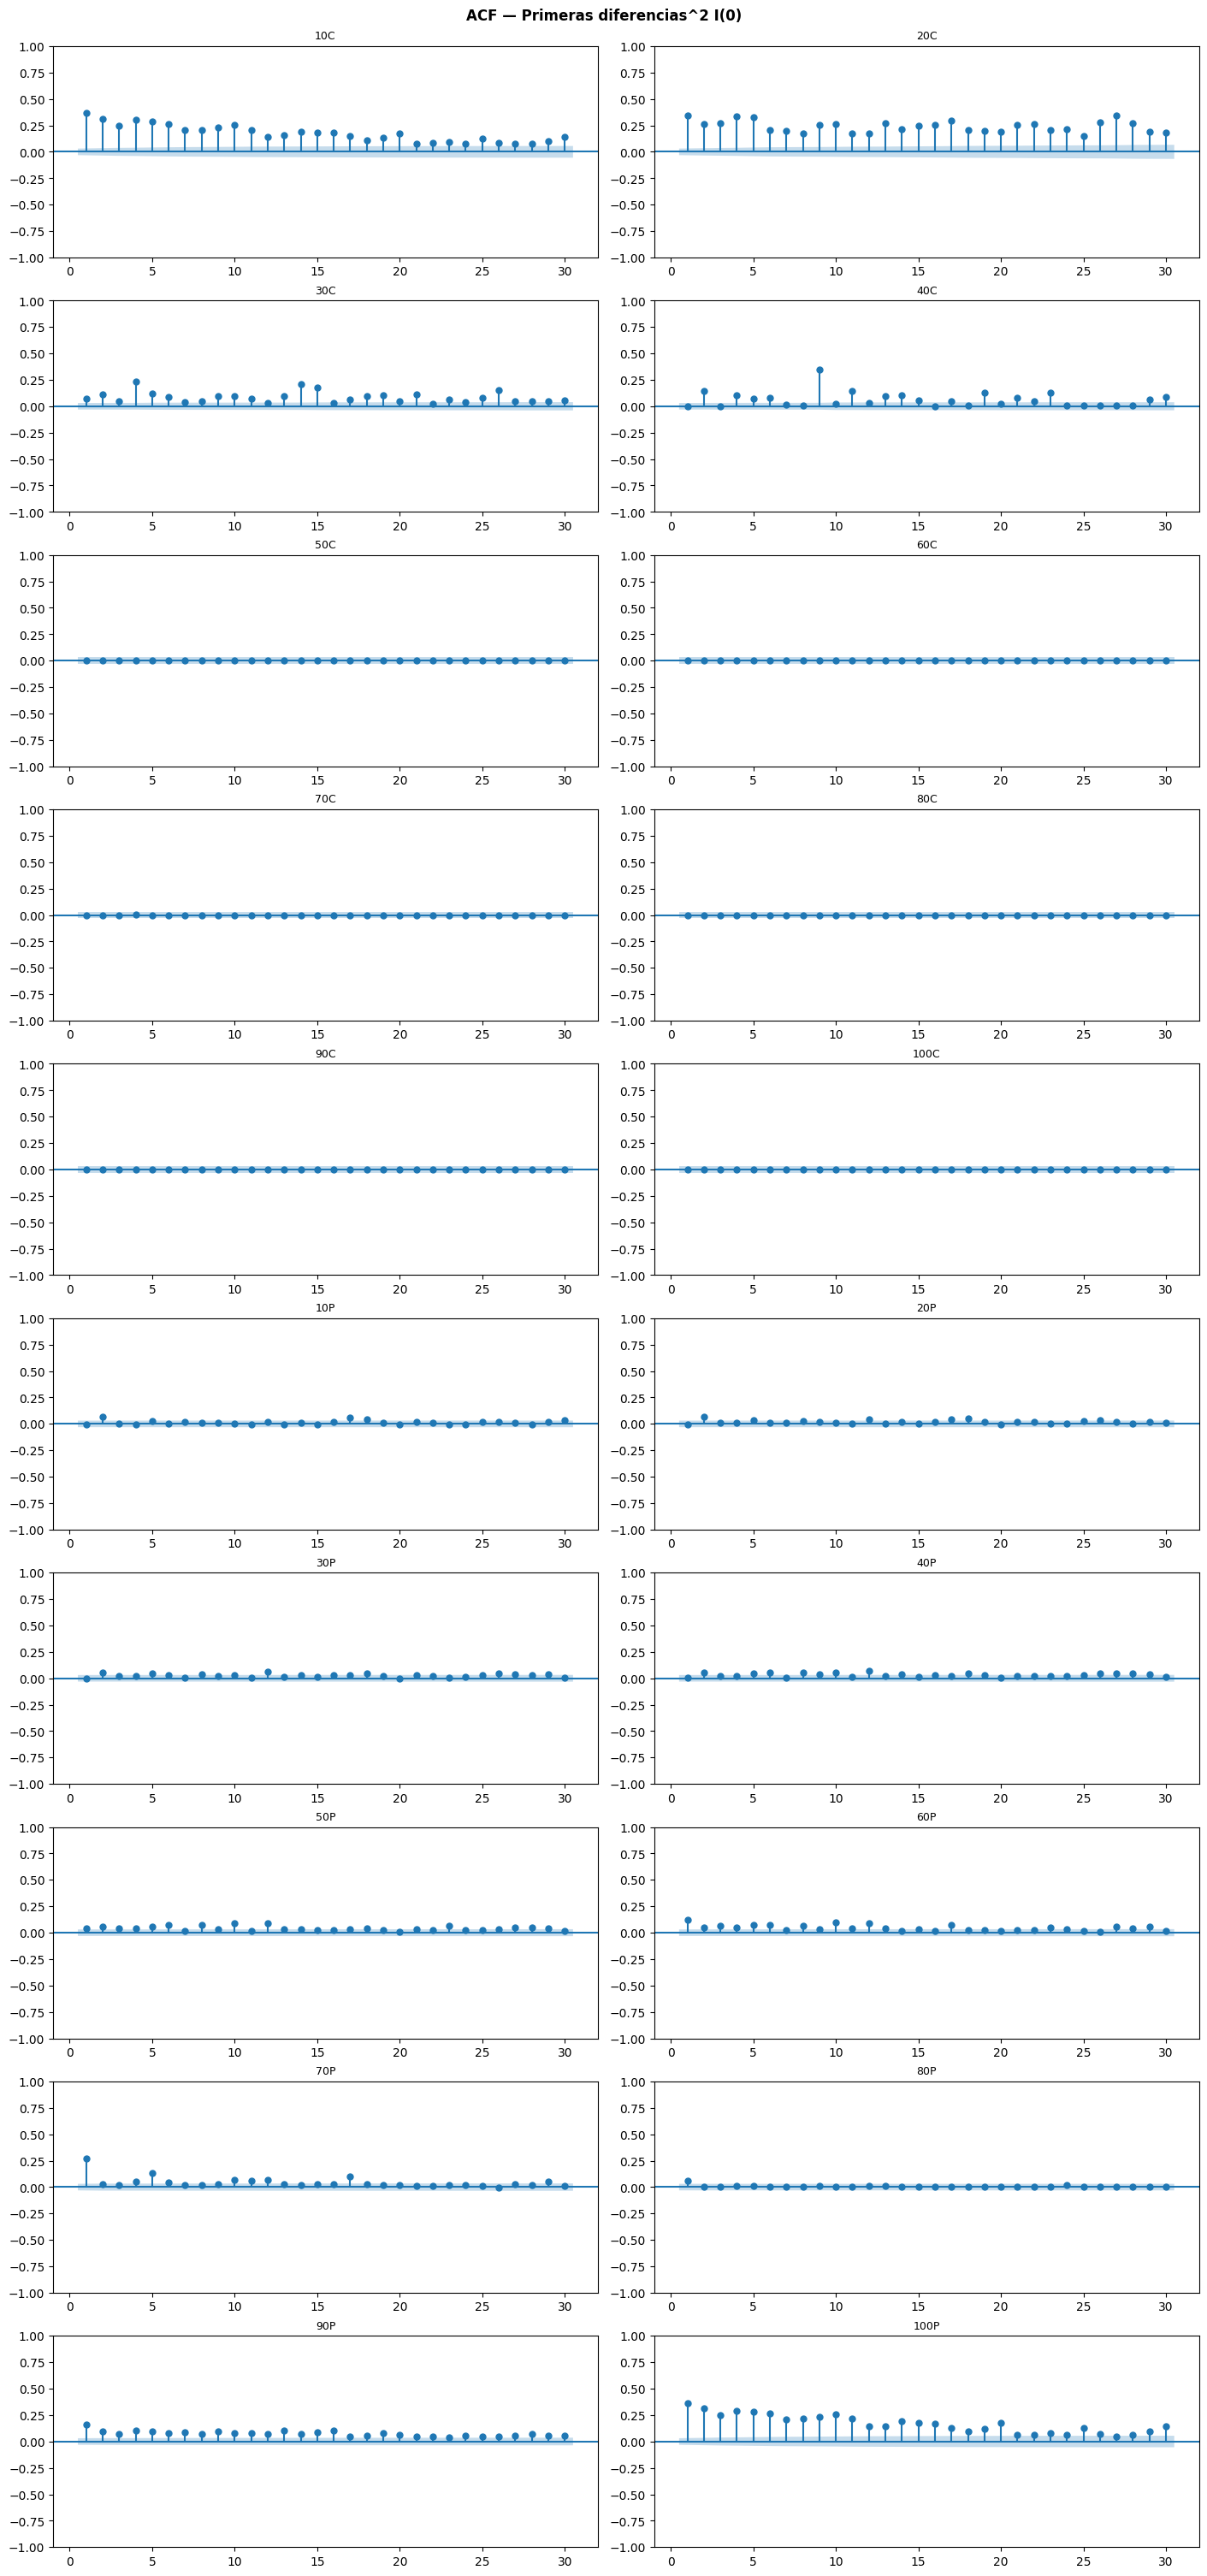

In [10]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

quantile_diff_sqrt = quantile_diff**2

for i, col in enumerate(cols_d):
    plot_acf(quantile_diff_sqrt[col].dropna(), lags=30, ax=axes[i], zero=False, alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):  
    axes[j].set_visible(False)

fig.suptitle("ACF — Primeras diferencias^2 I(0)", fontsize=12, fontweight="bold")
plt.show()


#### 7.4. Gráficas de PACF I(1) con diferencias al cuadrado:

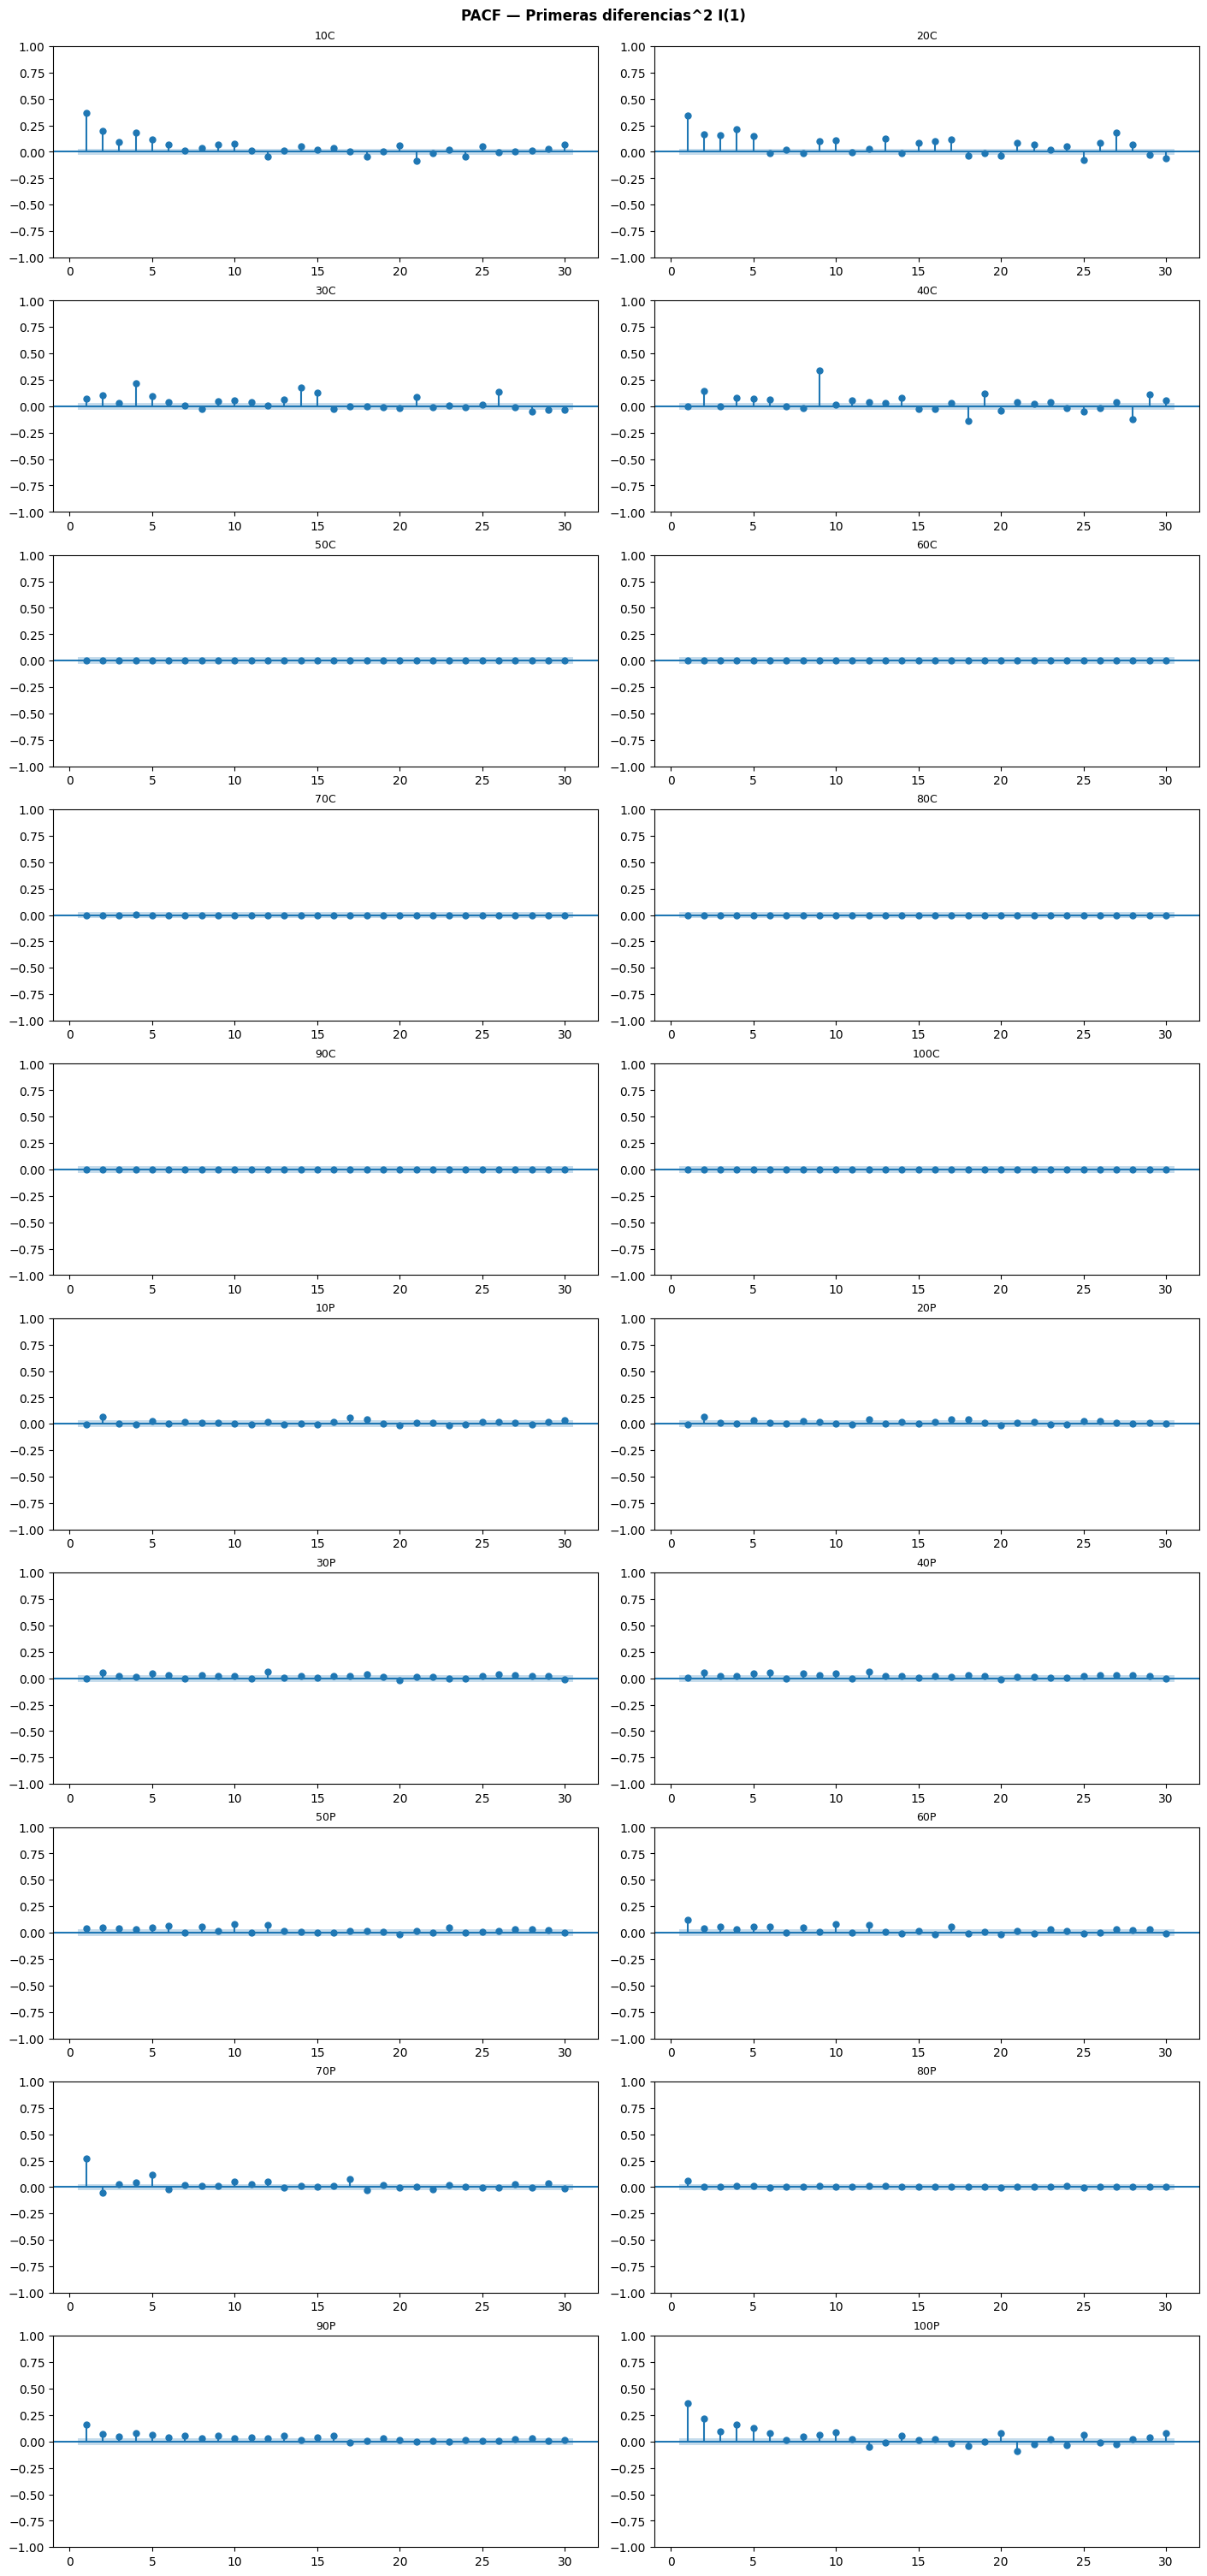

In [11]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_pacf(quantile_diff_sqrt[col], lags=30, ax=axes[i], zero=False, method="ols", alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("PACF — Primeras diferencias^2 I(1)", fontsize=12, fontweight="bold")
plt.show()
